In [1]:
import torch
import torch.nn as nn
from torch_geometric.loader import DataLoader
import numpy as np
from fairchem.core.datasets import AseDBDataset
import torch
from torch.nn import Linear, Dropout
from torch_geometric.nn import SchNet
from torch_geometric.data import Data
from torch_cluster import radius_graph
from torch_scatter import scatter
import matplotlib.pyplot as plt
from read_multi_ase import *
from extract_ab import *

W0504 23:37:37.569000 78231 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [ ]:
class EmbeddedSchNet(torch.nn.Module):
    def __init__(self,
                 hidden_channels: int = 128,
                 num_filters: int = 128,
                 num_interactions: int = 6,
                 num_gaussians: int = 50,
                 cutoff: int = 12,
                 max_num_neighbors: int = 32,
                 readout: str = "mean",
                 dipole: bool = False,
                 mean: float = None,
                 std: float = None,
                 atomref: torch.Tensor = None,
                 extra_feat_dim: int = 1,
                 train_mean: float = None,
                 train_std: float = None):
        super().__init__()

        #Create SchNet module with parameters
        self.schnet = SchNet(
            hidden_channels = hidden_channels,
            num_filters = num_filters,
            num_interactions = num_interactions,
            num_gaussians = num_gaussians,
            cutoff = cutoff,
            max_num_neighbors = max_num_neighbors,
            readout = readout,
            dipole = dipole,
            mean = mean,
            std = std,
            atomref = atomref)

        # self.dropout = Dropout(0.2)

        #Adjusted linear layer for two homo lumo gaps
        self.schnet.lin2 = Linear(self.schnet.hidden_channels // 2, 2)

        #Extra Linear layer to handle extra embedded features
        self.linear = Linear(extra_feat_dim, hidden_channels)

        #Keep track of training mean and std for normalization function
        self.mean = train_mean
        self.std = train_std

    def forward(self, data):
        #Extract each value from data
        atomic_num, positions, batch, extra_feat = data.z, data.pos, data.batch, data.extra_feat

        #Initialize atom embeddings through SchNet
        atom_embeddings = self.schnet.embedding(atomic_num)

        # print(extra_feat.shape)

        #Project extra features on linear layer
        extra_linear = self.linear(extra_feat)

        #Combine extra features and initialized atom embeddings
        atom_embeddings = atom_embeddings + extra_linear

        #Use SchNet utilities to extract edge indexes and edge weighs based on position and batch
        edge_index, edge_weight = self.schnet.interaction_graph(positions, batch)
        #Use SchNet utilities to obtain edge attribute based on edge weights
        edge_attr = self.schnet.distance_expansion(edge_weight)

        #Iterate through each interaction block manually to simulate Schnet
        for interaction_block in self.schnet.interactions:
            atom_embeddings = atom_embeddings + interaction_block(atom_embeddings, edge_index, edge_weight, edge_attr)

        atom_embeddings = self.schnet.lin1(atom_embeddings)

        # atom_embeddings = self.dropout(atom_embeddings)

        atom_embeddings = self.schnet.act(atom_embeddings)

        atom_embeddings = self.schnet.lin2(atom_embeddings)

        #Ensure the readout is based on model's hyperparameter
        output = self.schnet.readout(atom_embeddings, batch)

        return output

#Determine the device to be used
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#Initialize model with desired parameters
bio_model = EmbeddedSchNet(hidden_channels=128, num_filters=128, extra_feat_dim = 2).to(device)
#Create ADAM optimizer based on model's parameters and desired learning rate
optimizer = torch.optim.Adam(bio_model.parameters(), lr=5e-5)
#Select loss function for model
loss_function = torch.nn.SmoothL1Loss(reduction = "none")


def train(model: EmbeddedSchNet, train_data: list):
    model.train()
    #Keep track of total loss for all data
    total_train_loss = 0

    for data in train_data:
        data = data.to(device)

        #Reset optimizers
        optimizer.zero_grad()

        #Forward step internally performed by PyTorch to obtain predictions (Same as model.forward(data))
        y_pred = model(data)

        y_target = data.y.view(-1, 2)

        y_mask = data.y_mask.view(-1, 2)

        #Determine train loss based on loss function with predictions and targets
        train_loss = loss_function(y_pred, y_target)
        train_loss = (train_loss * y_mask).sum() / y_mask.sum()

        #Backward step to calculate gradients
        train_loss.backward()
        #Updated optimizers
        optimizer.step()

        #Add train loss of current data to total train loss
        total_train_loss += train_loss.item()

    return total_train_loss / len(train_data)

@torch.no_grad()
def evaluate(model: EmbeddedSchNet, val_data: list):
    model.eval()
    total_val_loss = 0

    for data in val_data:
        data = data.to(device)

        #Forward step internally performed by PyTorch to obtain predictions (Same as model.forward(data))
        y_pred = model(data)

        y_target = data.y.view(-1, 2)

        y_mask = data.y_mask.view(-1, 2)

        #Determine train loss based on loss function with predictions and targets
        val_loss = loss_function(y_pred, y_target)
        val_loss = (val_loss * y_mask).sum() / y_mask.sum()

        #Add validation loss of current data to total validation loss
        total_val_loss += val_loss.item()

    return total_val_loss / len(val_data)

@torch.no_grad()
def test(model: EmbeddedSchNet, test_data: list):
    model.eval()

    total_mae = 0
    total_mse = 0
    n_molecules = 0

    for data in test_data:
        data = data.to(device)

        y_pred = model(data)
        y_target = data.y.view(-1, 2)

        y_mask = data.y_mask.view(-1, 2)


        y_pred = (y_pred * model.std + model.mean) * y_mask
        y_target = (y_target * model.std + model.mean) * y_mask


        mae = torch.abs(y_pred - y_target).sum()
        mse = ((y_pred - y_target) ** 2).sum()

        total_mae += mae.item()
        total_mse += mse.item()
        n_molecules += y_mask.sum()

    mean_mae = total_mae / n_molecules
    rmse = (total_mse / n_molecules) ** 0.5

    return mean_mae, rmse


def plot_losses(train_loss, val_loss):
    """Plot training vs validation loss from a history dict."""
    plt.figure(figsize=(10, 6))
    plt.plot(train_loss, label='Train Loss', linewidth=2)
    plt.plot(val_loss, label='Validation Loss',
             linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('SchNet Model Training vs Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [143]:
@torch.no_grad()
def test(model: EmbeddedSchNet, test_data: list):
    model.eval()

    total_mae = 0
    total_mse = 0
    n_molecules = 0

    for data in test_data:
        data = data.to(device)

        y_pred = model(data)
        y_target = data.y.view(-1, 2)

        y_mask = data.y_mask.view(-1, 2)


        y_pred = (y_pred * model.std + model.mean) * y_mask
        y_target = (y_target * model.std + model.mean) * y_mask

        print(y_pred)
        print(y_target)

        mae = torch.abs(y_pred - y_target).sum()
        mse = ((y_pred - y_target) ** 2).sum()

        total_mae += mae.item()
        total_mse += mse.item()
        n_molecules += y_mask.sum()

    print(total_mae, n_molecules)
    mean_mae = total_mae / n_molecules
    rmse = (total_mse / n_molecules) ** 0.5

    return mean_mae, rmse

In [ ]:
bio_model = EmbeddedSchNet(hidden_channels = 128, num_filters = 128, cutoff= 10, num_interactions = 6, extra_feat_dim = 1).to(device)
optimizer = torch.optim.Adam(bio_model.parameters(), lr=5e-5, weight_decay=1e-4)

In [ ]:
bio_sample = process_file(file="./train_4M/data0000.aselmdb", molecule_type= "biomolecules", max_molecules = 2000)
bio_data = get_data(bio_sample, ["lowdin_charges"])
bio_train, bio_val, bio_test = split_data(bio_data, 0.2, 0.2)

Processed 2000 atoms


In [115]:
bio_train[0].y

tensor([0.9069, 0.0000])

In [ ]:
train_scaler = feature_scaler(bio_train)
bio_train = scale_features(bio_train, train_scaler)
bio_val = scale_features(bio_val, train_scaler)
bio_test = scale_features(bio_test, train_scaler)

bio_model.mean, bio_model.std = obtain_mean_std(bio_train)
bio_model.mean, bio_model.std
bio_train = normalize_target(bio_train, bio_model.mean, bio_model.std)
bio_val = normalize_target(bio_val, bio_model.mean, bio_model.std)
bio_test = normalize_target(bio_test, bio_model.mean, bio_model.std)

bio_train_loader = DataLoader(bio_train, batch_size=32, shuffle=True)
bio_val_loader = DataLoader(bio_val, batch_size=32)
bio_test_loader = DataLoader(bio_test, batch_size=32)

In [166]:
epochs = 80
bio_train_losses = np.zeros(epochs)
bio_val_losses = np.zeros(epochs)

for epoch in range(epochs):
    train_loss = train(bio_model, bio_train_loader)
    val_loss = evaluate(bio_model, bio_val_loader)

    bio_train_losses[epoch] = train_loss
    bio_val_losses[epoch] = val_loss
    if epoch % 5 == 0:
        print(f"Epoch {epoch + 1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 001 | Train Loss: 0.3691 | Val Loss: 0.3846
Epoch 006 | Train Loss: 0.2772 | Val Loss: 0.3441
Epoch 011 | Train Loss: 0.2605 | Val Loss: 0.3404
Epoch 016 | Train Loss: 0.2372 | Val Loss: 0.3234
Epoch 021 | Train Loss: 0.2251 | Val Loss: 0.3171
Epoch 026 | Train Loss: 0.2143 | Val Loss: 0.3097
Epoch 031 | Train Loss: 0.2093 | Val Loss: 0.3112
Epoch 036 | Train Loss: 0.2003 | Val Loss: 0.3007
Epoch 041 | Train Loss: 0.1921 | Val Loss: 0.2943
Epoch 046 | Train Loss: 0.1883 | Val Loss: 0.2847
Epoch 051 | Train Loss: 0.1782 | Val Loss: 0.2818
Epoch 056 | Train Loss: 0.1785 | Val Loss: 0.2814
Epoch 061 | Train Loss: 0.1676 | Val Loss: 0.2763
Epoch 066 | Train Loss: 0.1634 | Val Loss: 0.2692
Epoch 071 | Train Loss: 0.1514 | Val Loss: 0.2721
Epoch 076 | Train Loss: 0.1473 | Val Loss: 0.2753


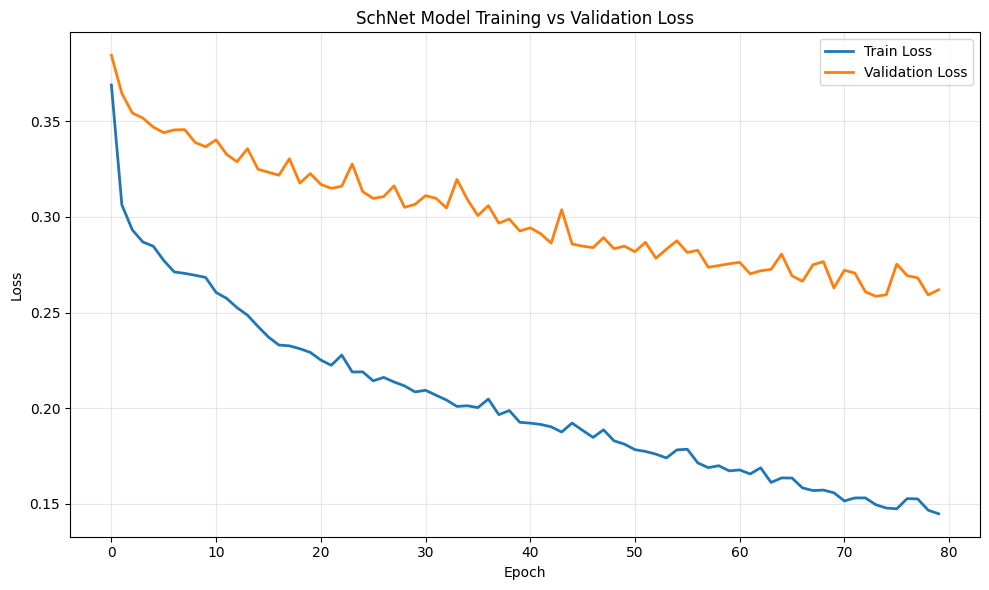

In [167]:
plot_losses(bio_train_losses, bio_val_losses)

In [168]:
mae, rmse = test(bio_model, bio_test_loader)

print(f"Test MAE:  {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Test MAE:  0.9570
Test RMSE: 1.4481


In [11]:
bio_train[0].y

tensor([ 0.9607, -1.3316])

In [7]:
for data in bio_train:
    print(data.y)

tensor([8.6500, 8.6500])
tensor([11.1790, 11.1790])
tensor([8.9641, 8.9641])
tensor([10.1185, 10.1185])
tensor([9.9850, 9.9850])
tensor([8.6751, 8.6751])
tensor([8.4044, 8.4044])
tensor([7.5013, 7.5013])
tensor([9.8678, 9.8678])
tensor([8.5206, 8.5206])
tensor([7.7244, 7.7244])
tensor([8.8273, 7.9476])
tensor([8.1409, 8.1409])
tensor([6.8989, 6.8989])
tensor([7.5361, 7.5361])
tensor([8.8953, 8.8953])
tensor([10.0468, 10.0468])
tensor([9.3198, 9.3198])
tensor([3.7573, 3.7573])
tensor([9.8275, 9.8275])
tensor([6.5561, 6.5561])
tensor([8.8405, 8.8405])
tensor([7.3006, 7.3006])
tensor([8.9355, 8.9355])
tensor([4.7175, 4.7175])
tensor([0.9069, 0.9069])
tensor([6.6349, 6.6349])
tensor([10.3134, 10.3134])
tensor([9.4698, 9.4698])
tensor([7.2044, 7.2044])
tensor([9.0239, 9.0239])
tensor([6.7346, 6.7346])
tensor([9.8909, 9.8909])
tensor([7.8490, 7.8490])
tensor([9.8880, 9.8880])
tensor([6.6659, 6.6659])
tensor([10.0638, 10.0638])
tensor([6.7912, 6.7912])
tensor([10.6234, 10.6234])
tensor([6.915

In [ ]:
bio_model = EmbeddedSchNet(hidden_channels = 128, num_filters = 128, cutoff= 8, num_gaussians= 100, num_interactions = 6, extra_feat_dim = 1).to(device)
optimizer = torch.optim.Adam(bio_model.parameters(), lr=5e-5, weight_decay=1e-4)

In [ ]:
bio_sample = process_file(file="./train_4M/data0000.aselmdb", molecule_type= "biomolecules", max_molecules = 1000)
bio_data = get_data(bio_sample, ["lowdin_charges"])
bio_train, bio_val, bio_test = split_data(bio_data, 0.2, 0.2)

Processed 1000 atoms


In [ ]:
train_scaler = feature_scaler(bio_train)
bio_train = scale_features(bio_train, train_scaler)
bio_val = scale_features(bio_val, train_scaler)
bio_test = scale_features(bio_test, train_scaler)

bio_model.mean, bio_model.std = obtain_mean_std(bio_train)
bio_model.mean, bio_model.std
bio_train = normalize_target(bio_train, bio_model.mean, bio_model.std)
bio_val = normalize_target(bio_val, bio_model.mean, bio_model.std)
bio_test = normalize_target(bio_test, bio_model.mean, bio_model.std)

bio_train_loader = DataLoader(bio_train, batch_size=32, shuffle=True)
bio_val_loader = DataLoader(bio_val, batch_size=32)
bio_test_loader = DataLoader(bio_test, batch_size=32)

(tensor(0.0188), tensor(1.0972))

In [172]:
epochs = 80
bio_train_losses = np.zeros(epochs)
bio_val_losses = np.zeros(epochs)

for epoch in range(epochs):
    train_loss = train(bio_model, bio_train_loader)
    val_loss = evaluate(bio_model, bio_val_loader)

    bio_train_losses[epoch] = train_loss
    bio_val_losses[epoch] = val_loss
    if epoch % 5 == 0:
        print(f"Epoch {epoch + 1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 001 | Train Loss: 0.3936 | Val Loss: 0.3197
Epoch 006 | Train Loss: 0.2906 | Val Loss: 0.2800
Epoch 011 | Train Loss: 0.2750 | Val Loss: 0.2786
Epoch 016 | Train Loss: 0.2588 | Val Loss: 0.2516
Epoch 021 | Train Loss: 0.2529 | Val Loss: 0.2462
Epoch 026 | Train Loss: 0.2462 | Val Loss: 0.2426
Epoch 031 | Train Loss: 0.2447 | Val Loss: 0.2329
Epoch 036 | Train Loss: 0.2306 | Val Loss: 0.2289
Epoch 041 | Train Loss: 0.2267 | Val Loss: 0.2334
Epoch 046 | Train Loss: 0.2160 | Val Loss: 0.2443
Epoch 051 | Train Loss: 0.2099 | Val Loss: 0.2204
Epoch 056 | Train Loss: 0.1987 | Val Loss: 0.2122
Epoch 061 | Train Loss: 0.1898 | Val Loss: 0.2117
Epoch 066 | Train Loss: 0.1910 | Val Loss: 0.2117
Epoch 071 | Train Loss: 0.1809 | Val Loss: 0.2131
Epoch 076 | Train Loss: 0.1753 | Val Loss: 0.2125


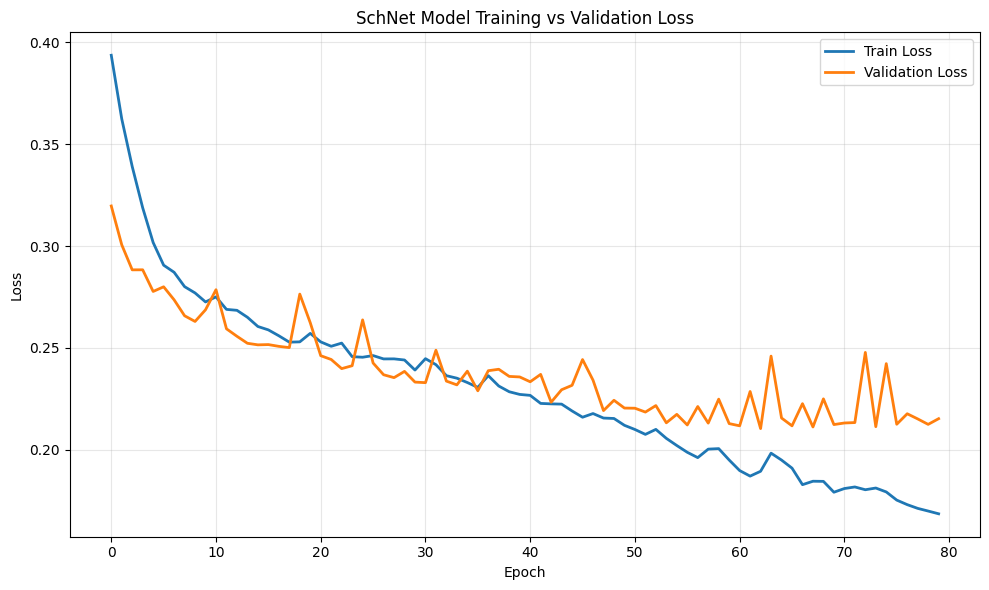

In [173]:
plot_losses(bio_train_losses, bio_val_losses)

In [174]:
mae, rmse = test(bio_model, bio_test_loader)

print(f"Test MAE:  {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Test MAE:  1.2413
Test RMSE: 1.9817


In [4]:
bio_model = EmbeddedSchNet(hidden_channels = 128, num_filters = 128, cutoff= 8, num_gaussians= 100, num_interactions = 6, extra_feat_dim = 1).to(device)
optimizer = torch.optim.Adam(bio_model.parameters(), lr=5e-5, weight_decay=1e-4)

In [5]:
bio_sample = process_file(file="./train_4M/data0000.aselmdb", molecule_type= "biomolecules", max_molecules = 1000)
bio_data = get_data(bio_sample, ["lowdin_charges"])
bio_train, bio_val, bio_test = split_data(bio_data, 0.2, 0.2)

Processed 1000 atoms


In [6]:
train_scaler = feature_scaler(bio_train)
bio_train = scale_features(bio_train, train_scaler)
bio_val = scale_features(bio_val, train_scaler)
bio_test = scale_features(bio_test, train_scaler)

bio_model.mean, bio_model.std = obtain_mean_std(bio_train)
bio_model.mean, bio_model.std
bio_train = normalize_target(bio_train, bio_model.mean, bio_model.std)
bio_val = normalize_target(bio_val, bio_model.mean, bio_model.std)
bio_test = normalize_target(bio_test, bio_model.mean, bio_model.std)

bio_train_loader = DataLoader(bio_train, batch_size=32, shuffle=True)
bio_val_loader = DataLoader(bio_val, batch_size=32)
bio_test_loader = DataLoader(bio_test, batch_size=32)

In [7]:
epochs = 50
bio_train_losses = np.zeros(epochs)
bio_val_losses = np.zeros(epochs)

for epoch in range(epochs):
    train_loss = train(bio_model, bio_train_loader)
    val_loss = evaluate(bio_model, bio_val_loader)

    bio_train_losses[epoch] = train_loss
    bio_val_losses[epoch] = val_loss
    if epoch % 5 == 0:
        print(f"Epoch {epoch + 1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 001 | Train Loss: 0.3952 | Val Loss: 0.3399
Epoch 006 | Train Loss: 0.2900 | Val Loss: 0.2464
Epoch 011 | Train Loss: 0.2723 | Val Loss: 0.2498
Epoch 016 | Train Loss: 0.2564 | Val Loss: 0.2426
Epoch 021 | Train Loss: 0.2491 | Val Loss: 0.2401
Epoch 026 | Train Loss: 0.2424 | Val Loss: 0.2363
Epoch 031 | Train Loss: 0.2370 | Val Loss: 0.2317
Epoch 036 | Train Loss: 0.2266 | Val Loss: 0.2266
Epoch 041 | Train Loss: 0.2248 | Val Loss: 0.2227
Epoch 046 | Train Loss: 0.2131 | Val Loss: 0.2171


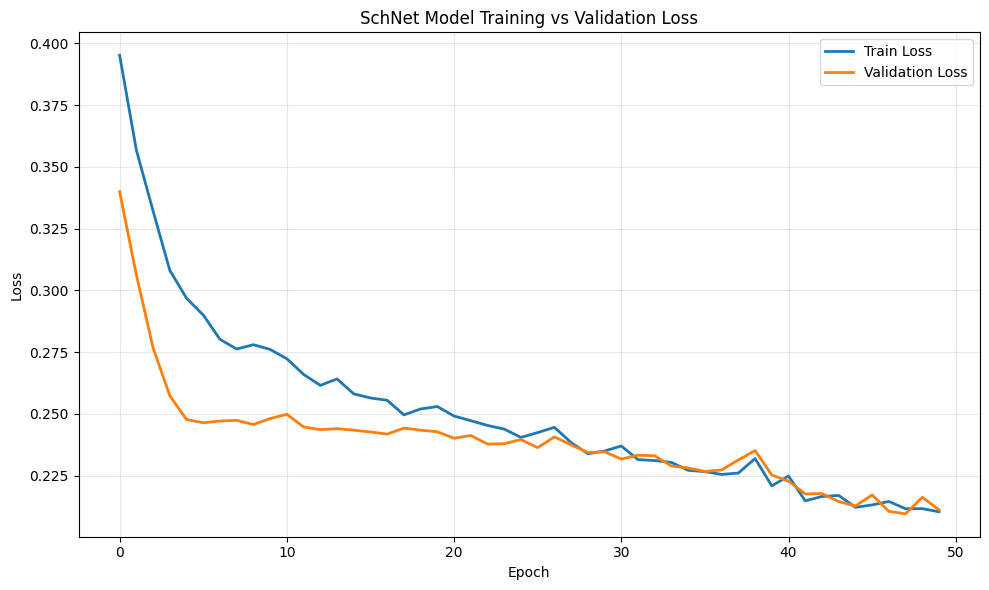

In [8]:
plot_losses(bio_train_losses, bio_val_losses)

In [9]:
mae, rmse = test(bio_model, bio_test_loader)

print(f"Test MAE:  {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Test MAE:  1.2136
Test RMSE: 1.7275


## output with dropout

In [ ]:
bio_model = EmbeddedSchNet(hidden_channels = 128, num_filters = 128, cutoff= 10, num_interactions = 6, extra_feat_dim = 2).to(device)
optimizer = torch.optim.Adam(bio_model.parameters(), lr=5e-5, weight_decay=1e-4)

In [32]:
bio_sample = process_file(file="./train_4M/data0000.aselmdb", molecule_type= "biomolecules", max_molecules = 2000)
bio_data = get_data(bio_sample, ["lowdin_charges"])
bio_train, bio_val, bio_test = split_data(bio_data, 0.2, 0.2)

Processed 2000 atoms


In [33]:
train_scaler = feature_scaler(bio_train)
bio_train = scale_features(bio_train, train_scaler)
bio_val = scale_features(bio_val, train_scaler)
bio_test = scale_features(bio_test, train_scaler)

bio_model.mean, bio_model.std = obtain_mean_std(bio_train)
bio_model.mean, bio_model.std
bio_train = normalize_target(bio_train, bio_model.mean, bio_model.std)
bio_val = normalize_target(bio_val, bio_model.mean, bio_model.std)
bio_test = normalize_target(bio_test, bio_model.mean, bio_model.std)

bio_train_loader = DataLoader(bio_train, batch_size=32, shuffle=True)
bio_val_loader = DataLoader(bio_val, batch_size=32)
bio_test_loader = DataLoader(bio_test, batch_size=32)

In [34]:
epochs = 50
bio_train_losses = np.zeros(epochs)
bio_val_losses = np.zeros(epochs)

for epoch in range(epochs):
    train_loss = train(bio_model, bio_train_loader)
    val_loss = evaluate(bio_model, bio_val_loader)

    bio_train_losses[epoch] = train_loss
    bio_val_losses[epoch] = val_loss
    if epoch % 5 == 0:
        print(f"Epoch {epoch + 1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 001 | Train Loss: 0.3729 | Val Loss: 0.3252
Epoch 006 | Train Loss: 0.2834 | Val Loss: 0.2763
Epoch 011 | Train Loss: 0.2615 | Val Loss: 0.2549
Epoch 016 | Train Loss: 0.2332 | Val Loss: 0.2413
Epoch 021 | Train Loss: 0.2364 | Val Loss: 0.2363
Epoch 026 | Train Loss: 0.2202 | Val Loss: 0.2372
Epoch 031 | Train Loss: 0.2153 | Val Loss: 0.2287
Epoch 036 | Train Loss: 0.2098 | Val Loss: 0.2368
Epoch 041 | Train Loss: 0.2024 | Val Loss: 0.2339
Epoch 046 | Train Loss: 0.1980 | Val Loss: 0.2282


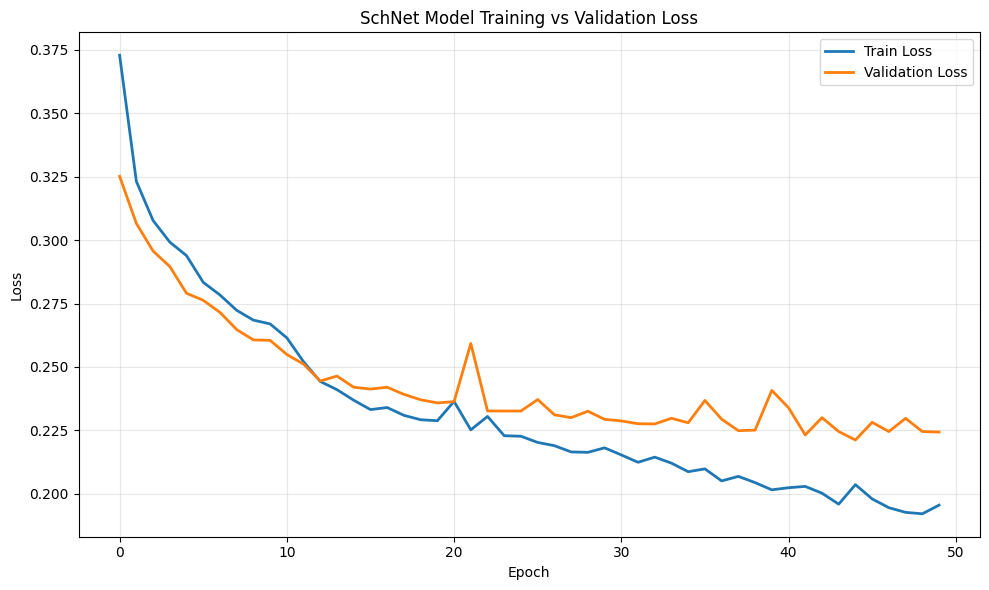

In [35]:
plot_losses(bio_train_losses, bio_val_losses)

In [36]:
mae, rmse = test(bio_model, bio_test_loader)

print(f"Test MAE:  {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Test MAE:  1.0830
Test RMSE: 1.6525


In [13]:
bio_model = EmbeddedSchNet(hidden_channels = 128, num_filters = 128, cutoff= 10, num_interactions = 6, extra_feat_dim = 2).to(device)
optimizer = torch.optim.AdamW(bio_model.parameters(), lr=5e-5, weight_decay=1e-5)

In [14]:
bio_sample = process_file(file="./train_4M/data0000.aselmdb", molecule_type= "biomolecules", max_molecules = 1000)
bio_data = get_data(bio_sample, ["lowdin_charges"])
bio_train, bio_val, bio_test = split_data(bio_data, 0.2, 0.2)

Processed 1000 atoms


In [15]:
train_scaler = feature_scaler(bio_train)
bio_train = scale_features(bio_train, train_scaler)
bio_val = scale_features(bio_val, train_scaler)
bio_test = scale_features(bio_test, train_scaler)

bio_model.mean, bio_model.std = obtain_mean_std(bio_train)
bio_model.mean, bio_model.std
bio_train = normalize_target(bio_train, bio_model.mean, bio_model.std)
bio_val = normalize_target(bio_val, bio_model.mean, bio_model.std)
bio_test = normalize_target(bio_test, bio_model.mean, bio_model.std)

bio_train_loader = DataLoader(bio_train, batch_size=32, shuffle=True)
bio_val_loader = DataLoader(bio_val, batch_size=32)
bio_test_loader = DataLoader(bio_test, batch_size=32)

In [ ]:
epochs = 50
bio_train_losses = np.zeros(epochs)
bio_val_losses = np.zeros(epochs)

for epoch in range(epochs):
    train_loss = train(bio_model, bio_train_loader)
    val_loss = evaluate(bio_model, bio_val_loader)

    bio_train_losses[epoch] = train_loss
    bio_val_losses[epoch] = val_loss
    if epoch % 5 == 0:
        print(f"Epoch {epoch + 1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

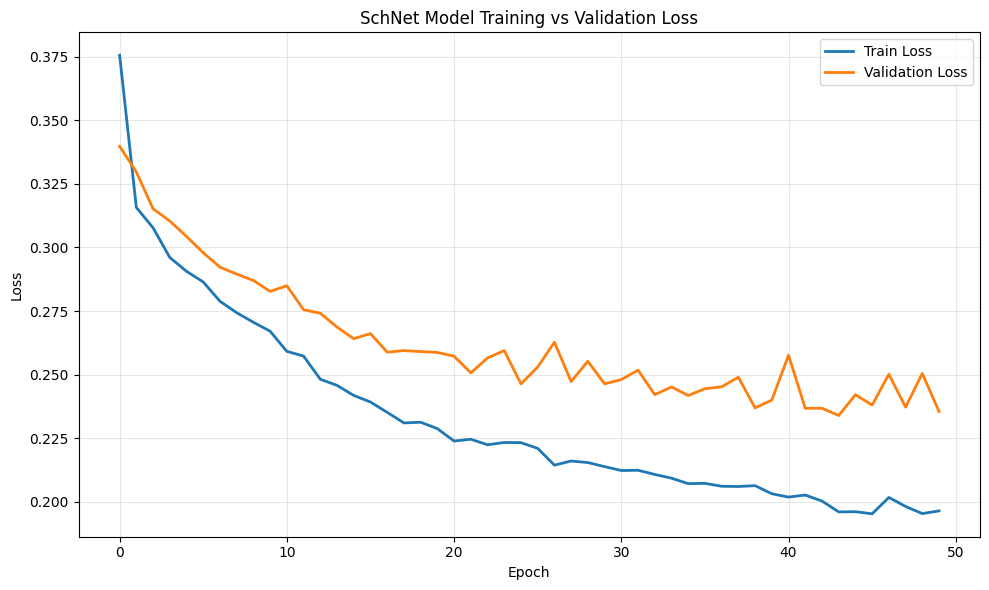

In [9]:
plot_losses(bio_train_losses, bio_val_losses)

In [10]:
mae, rmse = test(bio_model, bio_test_loader)

print(f"Test MAE:  {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Test MAE:  1.0762
Test RMSE: 1.6756


## Electronegativity + Lowdin

In [37]:
bio_model = EmbeddedSchNet(hidden_channels = 128, num_filters = 128, cutoff = 7, num_gaussians = 50, num_interactions = 5, extra_feat_dim = 2).to(device)
optimizer = torch.optim.Adam(bio_model.parameters(), lr=5e-5, weight_decay=5e-5)

In [38]:
bio_sample = process_file(file="./train_4M/data0000.aselmdb", molecule_type= "biomolecules", max_molecules = 1000)
bio_data = get_data(bio_sample, ["lowdin_charges"])
bio_train, bio_val, bio_test = split_data(bio_data, 0.2, 0.2)

Processed 1000 atoms


In [39]:
train_scaler = feature_scaler(bio_train)
bio_train = scale_features(bio_train, train_scaler)
bio_val = scale_features(bio_val, train_scaler)
bio_test = scale_features(bio_test, train_scaler)

bio_model.mean, bio_model.std = obtain_mean_std(bio_train)
bio_model.mean, bio_model.std
bio_train = normalize_target(bio_train, bio_model.mean, bio_model.std)
bio_val = normalize_target(bio_val, bio_model.mean, bio_model.std)
bio_test = normalize_target(bio_test, bio_model.mean, bio_model.std)

bio_train_loader = DataLoader(bio_train, batch_size=32, shuffle=True)
bio_val_loader = DataLoader(bio_val, batch_size=32)
bio_test_loader = DataLoader(bio_test, batch_size=32)

In [40]:
epochs = 50
bio_train_losses = np.zeros(epochs)
bio_val_losses = np.zeros(epochs)

for epoch in range(epochs):
    train_loss = train(bio_model, bio_train_loader)
    val_loss = evaluate(bio_model, bio_val_loader)

    bio_train_losses[epoch] = train_loss
    bio_val_losses[epoch] = val_loss
    if epoch % 5 == 0:
        print(f"Epoch {epoch + 1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 001 | Train Loss: 0.3744 | Val Loss: 0.3313
Epoch 006 | Train Loss: 0.3126 | Val Loss: 0.2802
Epoch 011 | Train Loss: 0.2930 | Val Loss: 0.2761
Epoch 016 | Train Loss: 0.2835 | Val Loss: 0.2640
Epoch 021 | Train Loss: 0.2719 | Val Loss: 0.2624
Epoch 026 | Train Loss: 0.2612 | Val Loss: 0.2554
Epoch 031 | Train Loss: 0.2562 | Val Loss: 0.2517
Epoch 036 | Train Loss: 0.2522 | Val Loss: 0.2504
Epoch 041 | Train Loss: 0.2408 | Val Loss: 0.2448
Epoch 046 | Train Loss: 0.2305 | Val Loss: 0.2390


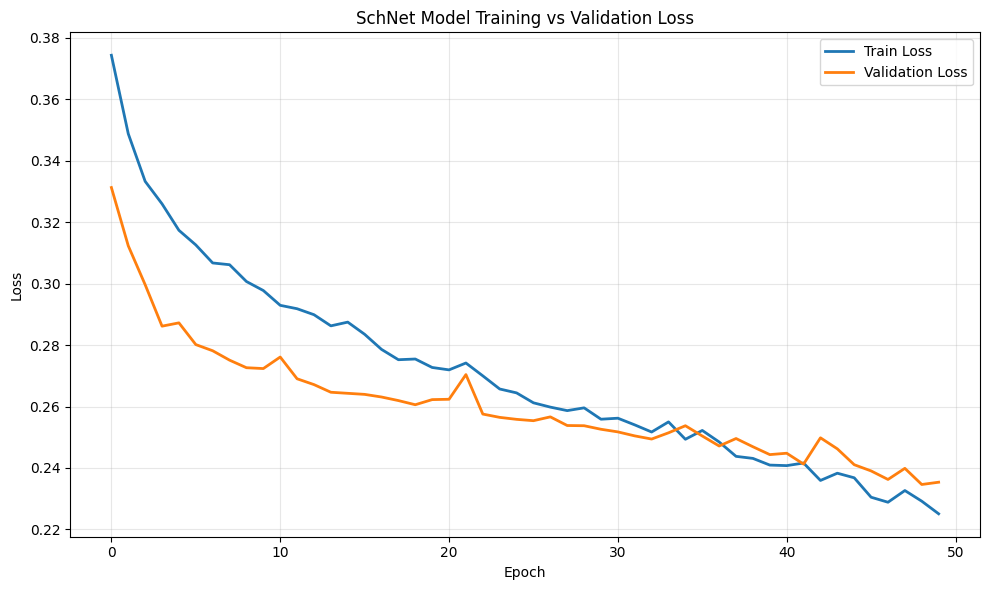

In [41]:
plot_losses(bio_train_losses, bio_val_losses)

In [42]:
mae, rmse = test(bio_model, bio_test_loader)

print(f"Test MAE:  {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Test MAE:  1.0501
Test RMSE: 1.5638


## Just lowdin

In [60]:
bio_model = EmbeddedSchNet(hidden_channels = 128, num_filters = 128, cutoff = 8, num_gaussians = 45, num_interactions = 6, extra_feat_dim = 1).to(device)
optimizer = torch.optim.Adam(bio_model.parameters(), lr=3e-5, weight_decay= 3e-5)

In [61]:
bio_sample = process_file(file="./train_4M/data0000.aselmdb", molecule_type= "biomolecules", max_molecules = 1000)
bio_data = get_data(bio_sample, ["lowdin_charges"])
bio_train, bio_val, bio_test = split_data(bio_data, 0.2, 0.2)

Processed 1000 atoms


In [62]:
train_scaler = feature_scaler(bio_train)
bio_train = scale_features(bio_train, train_scaler)
bio_val = scale_features(bio_val, train_scaler)
bio_test = scale_features(bio_test, train_scaler)

bio_model.mean, bio_model.std = obtain_mean_std(bio_train)
bio_model.mean, bio_model.std
bio_train = normalize_target(bio_train, bio_model.mean, bio_model.std)
bio_val = normalize_target(bio_val, bio_model.mean, bio_model.std)
bio_test = normalize_target(bio_test, bio_model.mean, bio_model.std)

bio_train_loader = DataLoader(bio_train, batch_size=32, shuffle=True)
bio_val_loader = DataLoader(bio_val, batch_size=32)
bio_test_loader = DataLoader(bio_test, batch_size=32)

In [63]:
epochs = 50
bio_train_losses = np.zeros(epochs)
bio_val_losses = np.zeros(epochs)

for epoch in range(epochs):
    train_loss = train(bio_model, bio_train_loader)
    val_loss = evaluate(bio_model, bio_val_loader)

    bio_train_losses[epoch] = train_loss
    bio_val_losses[epoch] = val_loss
    if epoch % 5 == 0:
        print(f"Epoch {epoch + 1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 001 | Train Loss: 0.3875 | Val Loss: 0.3204
Epoch 006 | Train Loss: 0.3029 | Val Loss: 0.2534
Epoch 011 | Train Loss: 0.2887 | Val Loss: 0.2382
Epoch 016 | Train Loss: 0.2809 | Val Loss: 0.2221
Epoch 021 | Train Loss: 0.2764 | Val Loss: 0.2152
Epoch 026 | Train Loss: 0.2691 | Val Loss: 0.2085
Epoch 031 | Train Loss: 0.2615 | Val Loss: 0.2024
Epoch 036 | Train Loss: 0.2555 | Val Loss: 0.1957
Epoch 041 | Train Loss: 0.2473 | Val Loss: 0.1937
Epoch 046 | Train Loss: 0.2384 | Val Loss: 0.1867


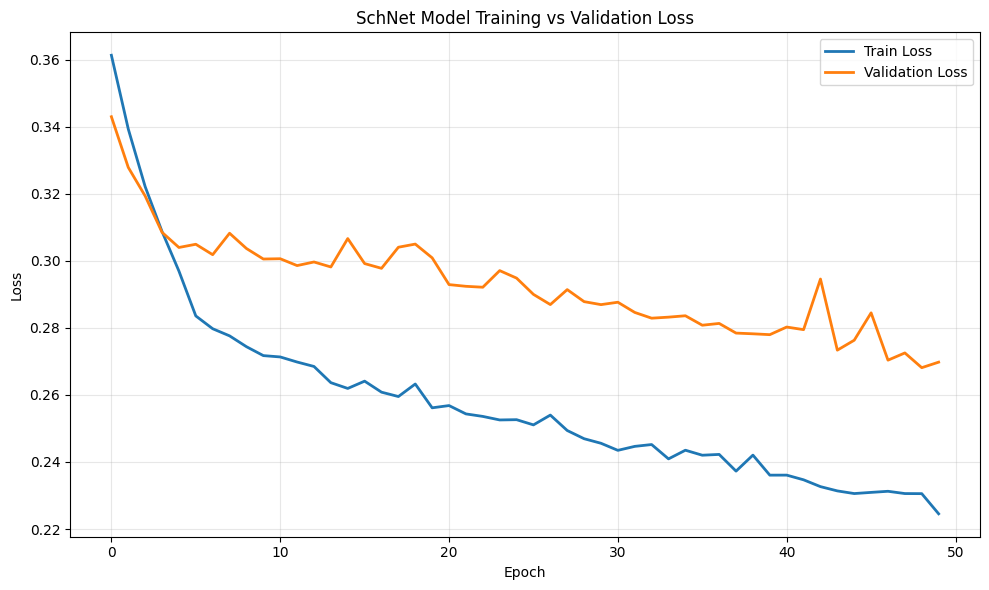

In [59]:
plot_losses(bio_train_losses, bio_val_losses)

In [50]:
mae, rmse = test(bio_model, bio_test_loader)

print(f"Test MAE:  {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Test MAE:  1.2825
Test RMSE: 1.9195


## Electronegativity + lowdin for 5000 molecules

In [ ]:
bio_model = EmbeddedSchNet(hidden_channels = 128, num_filters = 128, cutoff = 8, num_gaussians = 50, num_interactions = 5, extra_feat_dim = 2).to(device)
optimizer = torch.optim.AdamW(bio_model.parameters(), lr=1e-4, weight_decay=1e-5)

In [18]:
bio_sample = process_file(file="./train_4M/data0000.aselmdb", molecule_type= "biomolecules", max_molecules = 5000)
bio_data = get_data(bio_sample, ["lowdin_charges"])
bio_train, bio_val, bio_test = split_data(bio_data, 0.2, 0.2)

Processed 5000 atoms


In [19]:
train_scaler = feature_scaler(bio_train)
bio_train = scale_features(bio_train, train_scaler)
bio_val = scale_features(bio_val, train_scaler)
bio_test = scale_features(bio_test, train_scaler)

bio_model.mean, bio_model.std = obtain_mean_std(bio_train)
bio_model.mean, bio_model.std
bio_train = normalize_target(bio_train, bio_model.mean, bio_model.std)
bio_val = normalize_target(bio_val, bio_model.mean, bio_model.std)
bio_test = normalize_target(bio_test, bio_model.mean, bio_model.std)

bio_train_loader = DataLoader(bio_train, batch_size=32, shuffle=True)
bio_val_loader = DataLoader(bio_val, batch_size=32)
bio_test_loader = DataLoader(bio_test, batch_size=32)

In [20]:
epochs = 50
bio_train_losses = np.zeros(epochs)
bio_val_losses = np.zeros(epochs)

for epoch in range(epochs):
    train_loss = train(bio_model, bio_train_loader)
    val_loss = evaluate(bio_model, bio_val_loader)

    bio_train_losses[epoch] = train_loss
    bio_val_losses[epoch] = val_loss
    if epoch % 5 == 0:
        print(f"Epoch {epoch + 1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 001 | Train Loss: 0.3373 | Val Loss: 0.3318
Epoch 006 | Train Loss: 0.2703 | Val Loss: 0.2942
Epoch 011 | Train Loss: 0.2480 | Val Loss: 0.2587
Epoch 016 | Train Loss: 0.2322 | Val Loss: 0.2466
Epoch 021 | Train Loss: 0.2209 | Val Loss: 0.2400
Epoch 026 | Train Loss: 0.2112 | Val Loss: 0.2263
Epoch 031 | Train Loss: 0.1987 | Val Loss: 0.2164
Epoch 036 | Train Loss: 0.1903 | Val Loss: 0.2125
Epoch 041 | Train Loss: 0.1847 | Val Loss: 0.2102
Epoch 046 | Train Loss: 0.1764 | Val Loss: 0.2112


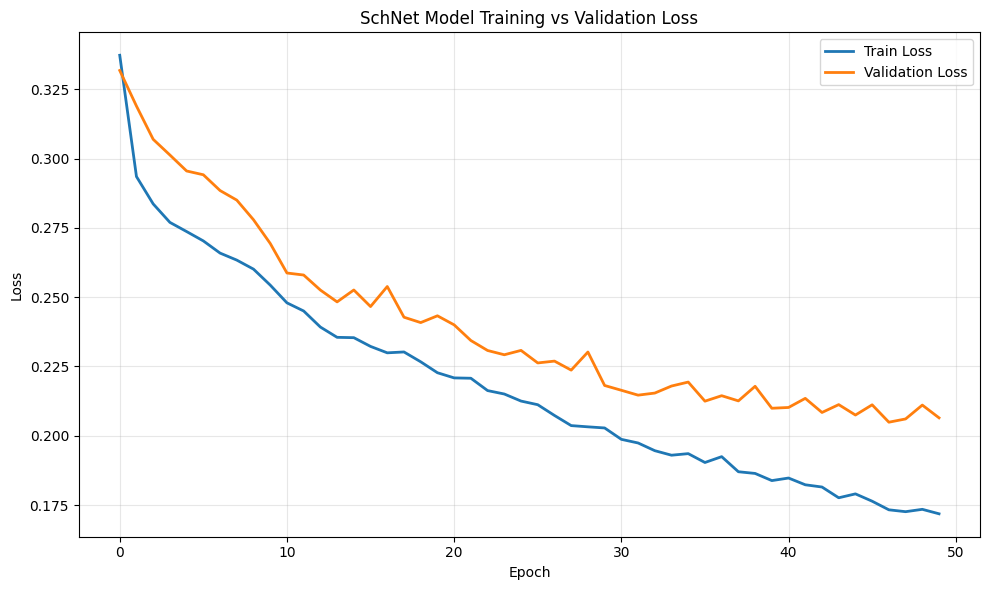

In [21]:
plot_losses(bio_train_losses, bio_val_losses)

In [22]:
mae, rmse = test(bio_model, bio_test_loader)

print(f"Test MAE:  {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Test MAE:  0.8916
Test RMSE: 1.3351


## Run on all types of molecules

In [4]:
bio_model = EmbeddedSchNet(hidden_channels = 128, num_filters = 128, cutoff = 8, num_gaussians = 50, num_interactions = 6, extra_feat_dim = 1).to(device)
optimizer = torch.optim.AdamW(bio_model.parameters(), lr=1e-4, weight_decay=1e-5)

In [5]:
bio_sample = process_file(file="./train_4M/data0000.aselmdb", molecule_type= None, max_molecules = 1000)
bio_data = get_data(bio_sample, ["lowdin_charges"])
bio_train, bio_val, bio_test = split_data(bio_data, 0.2, 0.2)

[ 0  1  3  4  5  6  7  8  9 11 12 13 14 15 16 17 19 20 21 22 23 24 25 26
 27 28 29 30 31 32 33 34 35 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51
 52 53 55 56 57 58 61 62 63 66 68 69 70 71 72 73 74 75 76 77 78 79 80 81
 82 83]
Processed 1000 atoms


In [6]:
train_scaler = feature_scaler(bio_train)
bio_train = scale_features(bio_train, train_scaler)
bio_val = scale_features(bio_val, train_scaler)
bio_test = scale_features(bio_test, train_scaler)

bio_model.mean, bio_model.std = obtain_mean_std(bio_train)
bio_model.mean, bio_model.std
bio_train = normalize_target(bio_train, bio_model.mean, bio_model.std)
bio_val = normalize_target(bio_val, bio_model.mean, bio_model.std)
bio_test = normalize_target(bio_test, bio_model.mean, bio_model.std)

bio_train_loader = DataLoader(bio_train, batch_size=32, shuffle=True)
bio_val_loader = DataLoader(bio_val, batch_size=32)
bio_test_loader = DataLoader(bio_test, batch_size=32)

In [7]:
epochs = 50
bio_train_losses = np.zeros(epochs)
bio_val_losses = np.zeros(epochs)

for epoch in range(epochs):
    train_loss = train(bio_model, bio_train_loader)
    val_loss = evaluate(bio_model, bio_val_loader)

    bio_train_losses[epoch] = train_loss
    bio_val_losses[epoch] = val_loss
    if epoch % 5 == 0:
        print(f"Epoch {epoch + 1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 001 | Train Loss: 0.4102 | Val Loss: 0.3101
Epoch 006 | Train Loss: 0.2643 | Val Loss: 0.2844
Epoch 011 | Train Loss: 0.2583 | Val Loss: 0.2833
Epoch 016 | Train Loss: 0.2348 | Val Loss: 0.2614
Epoch 021 | Train Loss: 0.2213 | Val Loss: 0.2542
Epoch 026 | Train Loss: 0.2044 | Val Loss: 0.2432
Epoch 031 | Train Loss: 0.1995 | Val Loss: 0.2515
Epoch 036 | Train Loss: 0.1848 | Val Loss: 0.2409
Epoch 041 | Train Loss: 0.1759 | Val Loss: 0.2554
Epoch 046 | Train Loss: 0.1659 | Val Loss: 0.2423


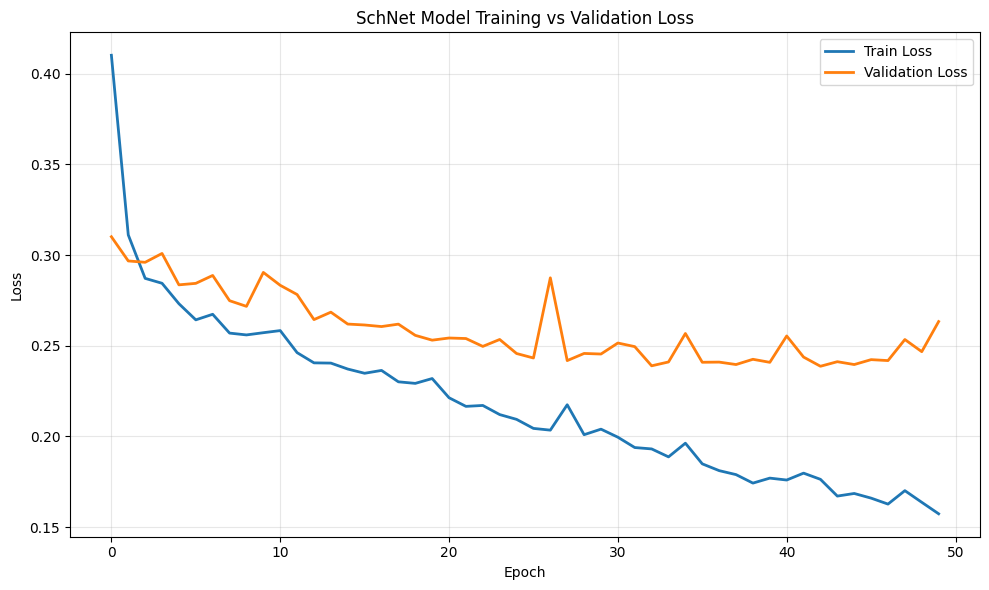

In [8]:
plot_losses(bio_train_losses, bio_val_losses)

In [ ]:
mae, rmse = test(bio_model, bio_test_loader)

print(f"Test MAE:  {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Test MAE:  1.2814
Test RMSE: 1.7987


## lowdin with 5000 molecules

In [10]:
bio_model = EmbeddedSchNet(hidden_channels = 128, num_filters = 128, cutoff = 8, num_gaussians = 50, num_interactions = 5, extra_feat_dim = 1).to(device)
optimizer = torch.optim.AdamW(bio_model.parameters(), lr=1e-4, weight_decay=1e-4)

In [11]:
bio_sample = process_file(file="./train_4M/data0000.aselmdb", molecule_type= "biomolecules", max_molecules = 5000)
bio_data = get_data(bio_sample, ["lowdin_charges"])
bio_train, bio_val, bio_test = split_data(bio_data, 0.2, 0.2)

[ 0  1  6  7  8  9 12 15 16 17 20 34 35 53 76]
Processed 5000 atoms


In [12]:
train_scaler = feature_scaler(bio_train)
bio_train = scale_features(bio_train, train_scaler)
bio_val = scale_features(bio_val, train_scaler)
bio_test = scale_features(bio_test, train_scaler)

bio_model.mean, bio_model.std = obtain_mean_std(bio_train)
bio_model.mean, bio_model.std
bio_train = normalize_target(bio_train, bio_model.mean, bio_model.std)
bio_val = normalize_target(bio_val, bio_model.mean, bio_model.std)
bio_test = normalize_target(bio_test, bio_model.mean, bio_model.std)

bio_train_loader = DataLoader(bio_train, batch_size=32, shuffle=True)
bio_val_loader = DataLoader(bio_val, batch_size=32)
bio_test_loader = DataLoader(bio_test, batch_size=32)

In [13]:
epochs = 50
bio_train_losses = np.zeros(epochs)
bio_val_losses = np.zeros(epochs)

for epoch in range(epochs):
    train_loss = train(bio_model, bio_train_loader)
    val_loss = evaluate(bio_model, bio_val_loader)

    bio_train_losses[epoch] = train_loss
    bio_val_losses[epoch] = val_loss
    if epoch % 5 == 0:
        print(f"Epoch {epoch + 1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 001 | Train Loss: 0.3239 | Val Loss: 0.2713
Epoch 006 | Train Loss: 0.2368 | Val Loss: 0.2306
Epoch 011 | Train Loss: 0.2176 | Val Loss: 0.2141
Epoch 016 | Train Loss: 0.2027 | Val Loss: 0.1968
Epoch 021 | Train Loss: 0.1838 | Val Loss: 0.1953
Epoch 026 | Train Loss: 0.1733 | Val Loss: 0.1850
Epoch 031 | Train Loss: 0.1607 | Val Loss: 0.1704
Epoch 036 | Train Loss: 0.1490 | Val Loss: 0.1778
Epoch 041 | Train Loss: 0.1438 | Val Loss: 0.1780
Epoch 046 | Train Loss: 0.1273 | Val Loss: 0.1653


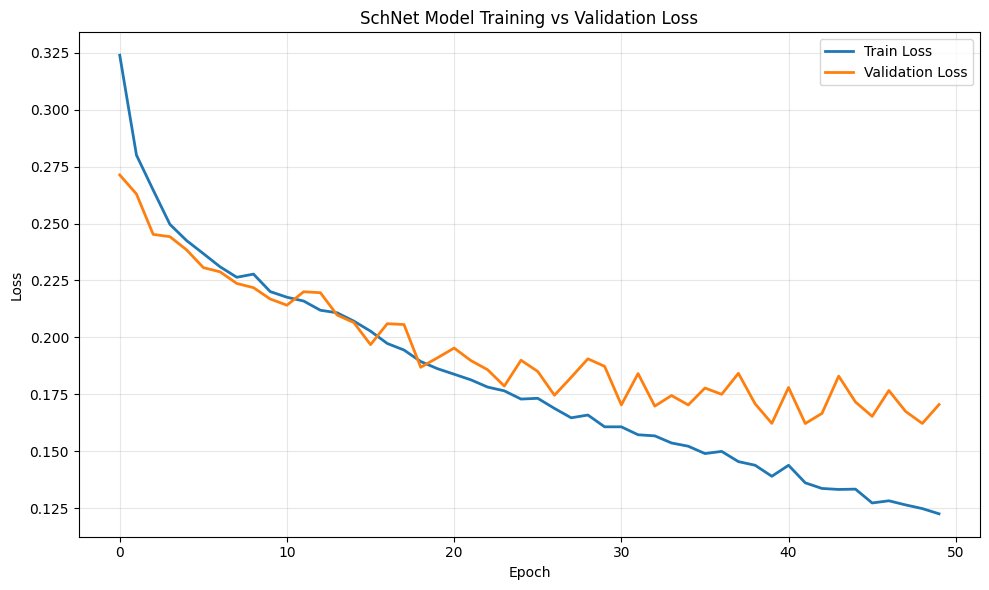

In [14]:
plot_losses(bio_train_losses, bio_val_losses)

In [15]:
mae, rmse = test(bio_model, bio_test_loader)

print(f"Test MAE:  {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Test MAE:  0.9395
Test RMSE: 1.4429


## Electronegativity + lowdin for 5000 molecules

In [3]:
bio_model = EmbeddedSchNet(hidden_channels = 128, num_filters = 128, cutoff = 8, num_gaussians = 50, num_interactions = 5, extra_feat_dim = 2).to(device)
optimizer = torch.optim.AdamW(bio_model.parameters(), lr=5e-5, weight_decay=1e-5)

In [4]:
bio_sample = process_file(file="./train_4M/data0000.aselmdb", molecule_type= "biomolecules", max_molecules = 10000)
bio_data = get_data(bio_sample, ["lowdin_charges"])
bio_train, bio_val, bio_test = split_data(bio_data, 0.2, 0.2)

Processed 10000 atoms


In [5]:
train_scaler = feature_scaler(bio_train)
bio_train = scale_features(bio_train, train_scaler)
bio_val = scale_features(bio_val, train_scaler)
bio_test = scale_features(bio_test, train_scaler)

bio_model.mean, bio_model.std = obtain_mean_std(bio_train)
bio_train = normalize_target(bio_train, bio_model.mean, bio_model.std)
bio_val = normalize_target(bio_val, bio_model.mean, bio_model.std)
bio_test = normalize_target(bio_test, bio_model.mean, bio_model.std)

bio_train_loader = DataLoader(bio_train, batch_size=32, shuffle=True)
bio_val_loader = DataLoader(bio_val, batch_size=32)
bio_test_loader = DataLoader(bio_test, batch_size=32)

In [6]:
epochs = 50
bio_train_losses = np.zeros(epochs)
bio_val_losses = np.zeros(epochs)

for epoch in range(epochs):
    train_loss = train(bio_model, bio_train_loader)
    val_loss = evaluate(bio_model, bio_val_loader)

    bio_train_losses[epoch] = train_loss
    bio_val_losses[epoch] = val_loss
    if epoch % 5 == 0:
        print(f"Epoch {epoch + 1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 001 | Train Loss: 0.3296 | Val Loss: 0.2825
Epoch 006 | Train Loss: 0.2433 | Val Loss: 0.2446
Epoch 011 | Train Loss: 0.2239 | Val Loss: 0.2200
Epoch 016 | Train Loss: 0.2059 | Val Loss: 0.2102
Epoch 021 | Train Loss: 0.1957 | Val Loss: 0.2065
Epoch 026 | Train Loss: 0.1854 | Val Loss: 0.1954
Epoch 031 | Train Loss: 0.1749 | Val Loss: 0.1872
Epoch 036 | Train Loss: 0.1663 | Val Loss: 0.1860
Epoch 041 | Train Loss: 0.1576 | Val Loss: 0.1817
Epoch 046 | Train Loss: 0.1524 | Val Loss: 0.1771


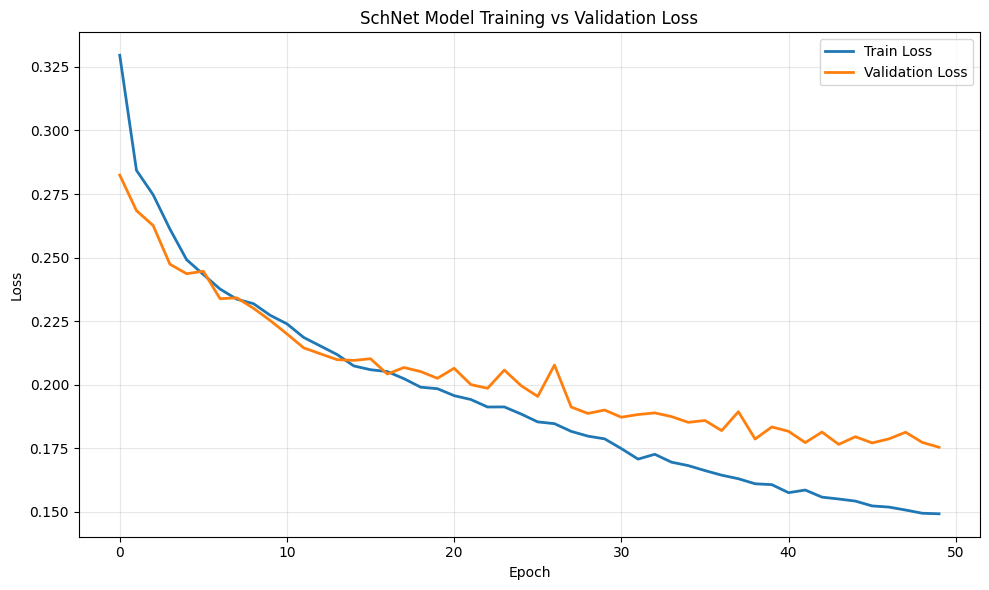

In [7]:
plot_losses(bio_train_losses, bio_val_losses)

In [8]:
mae, rmse = test(bio_model, bio_test_loader)

print(f"Test MAE:  {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Test MAE:  0.8664
Test RMSE: 1.3227
